<a href="https://colab.research.google.com/github/anutishah/anutishah/blob/main/AICodeProjectjyr3umnpw8uc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Looking at the Big Picture



### Getting the Data

In [ ]:
import pandas as pd
import sklearn
import numpy as np
import os
import matplotlib.pyplot as plt

np.random.seed(42)

def load_data(crashes_filtered_path="crashes_filtered.csv"):
    path = os.path.join(crashes_filtered_path)
    return pd.read_csv(path)

crashes_filtered = load_data()
crashes_filtered.head(5)

,X,Y,OBJECTID,DOCUMENT_NBR,CRASH_YEAR,CRASH_DT,CRASH_MILITARY_TM,CRASH_SEVERITY,K_PEOPLE,A_PEOPLE,...,AREA_TYPE,SYSTEM,VSP,OWNERSHIP,PLAN_DISTRICT,MPO_NAME,RTE_NM,RNS_MP,NODE,OFFSET
0,-77.413541,38.850280,621525,211405033,2021,2021/05/18 04:00:00+00,1755,PDO. Property Damage Only,0,0,...,Urban,VDOT Interstate,7.0,1. State Hwy Agency,Northern Virginia,Northern Virginia Portion of The Metropolitan ...,R-VA IS00066WB,54.52,NaN,NaN
1,-77.210753,38.930540,621526,213475367,2021,2021/12/08 05:00:00+00,2000,PDO. Property Damage Only,0,0,...,Urban,VDOT Interstate,7.0,1. State Hwy Agency,Northern Virginia,Northern Virginia Portion of The Metropolitan ...,R-VA IS00495NB,12.19,NaN,NaN
2,-77.247049,38.879815,621530,211815206,2021,2021/06/29 04:00:00+00,900,PDO. Property Damage Only,0,0,...,Urban,VDOT Interstate,7.0,1. State Hwy Agency,Northern Virginia,Northern Virginia Portion of The Metropolitan ...,R-VA IS00066WB,63.75,NaN,NaN
3,-77.180200,38.781013,621535,212255270,2021,2021/08/13 04:00:00+00,1640,PDO. Property Damage Only,0,0,...,Urban,VDOT Interstate,7.0,1. State Hwy Agency,Northern Virginia,Northern Virginia Portion of The Metropolitan ...,R-VA IS00095SB,170.35,NaN,NaN
4,-77.118580,38.827720,621537,212445121,2021,2021/08/27 04:00:00+00,1251,PDO. Property Damage Only,0,0,...,Urban,VDOT Interstate,7.0,1. State Hwy Agency,Northern Virginia,Northern Virginia Portion of The Metropolitan ...,R-VA IS00395SB,4.92,NaN,NaN


In [ ]:
crashes_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11817 entries, 0 to 11816
Data columns (total 69 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   X                         11816 non-null  float64
 1   Y                         11816 non-null  float64
 2   OBJECTID                  11817 non-null  int64  
 3   DOCUMENT_NBR              11817 non-null  int64  
 4   CRASH_YEAR                11817 non-null  int64  
 5   CRASH_DT                  11817 non-null  object 
 6   CRASH_MILITARY_TM         11817 non-null  int64  
 7   CRASH_SEVERITY            11817 non-null  object 
 8   K_PEOPLE                  11817 non-null  int64  
 9   A_PEOPLE                  11817 non-null  int64  
 10  B_PEOPLE                  11817 non-null  int64  
 11  C_PEOPLE                  11817 non-null  int64  
 12  PERSONS_INJURED           11817 non-null  int64  
 13  PEDESTRIANS_KILLED        11817 non-null  int64  
 14  PEDEST

The data will be filtered before the visualizing step since the amount of entries in the data set exceeds 1 million, which would make future processing take too long. We will be filtering the data based on crashes occuring in Northern Virginia and during the year of 2021 and onwards to have more relevant data to our local area to determine which roadways need a maintenance check.

### Visulaizing Data

In [ ]:
pip install cartopy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 126.1 MB/s eta 0:00:00


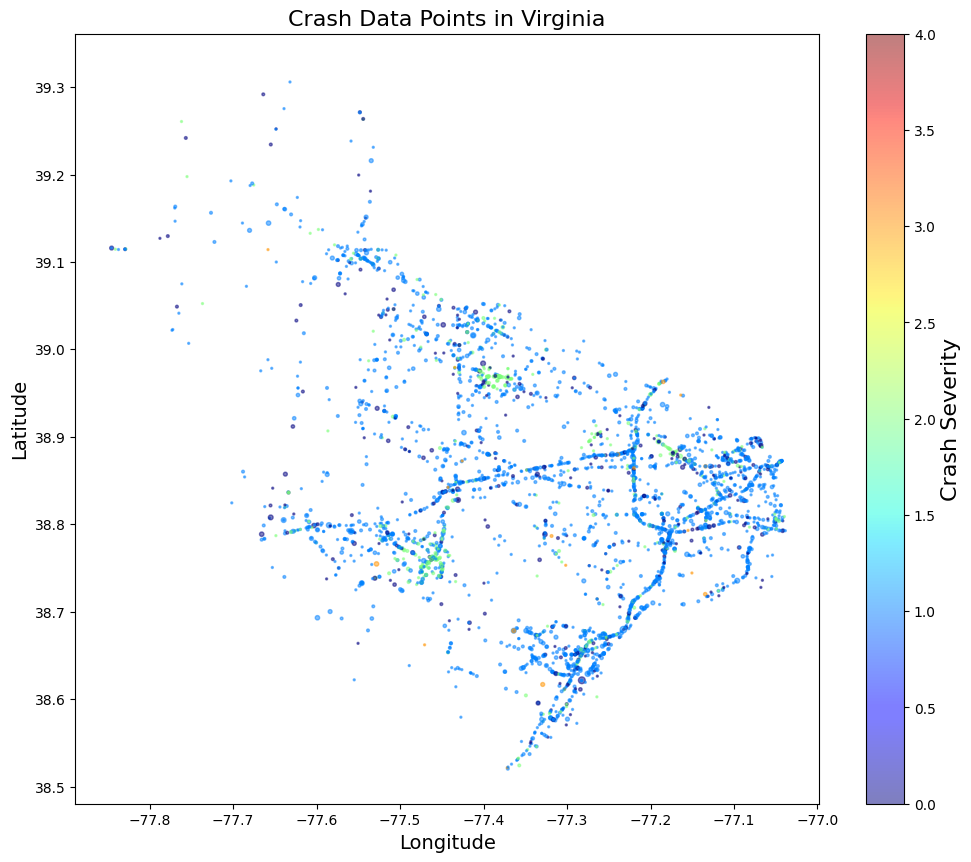

In [ ]:
%matplotlib inline
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#Plotting locations of the crashes, highlighting the number of people injured (by the size of the point) and crash severity (by the color)
crash_data = crashes_filtered
crash_data = crash_data.dropna(subset=['X', 'Y'])
plt.figure(figsize=(12, 10))

plt.scatter(
    crash_data['X'],
    crash_data['Y'],
    s=crash_data['PERSONS_INJURED'] * 2,
    c=crash_data['CRASH_SEVERITY'].astype('category').cat.codes,
    cmap=plt.get_cmap("jet"),
    alpha=0.5
)

plt.title('Crash Data Points in Virginia', fontsize=16)
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)
cbar = plt.colorbar()
cbar.set_label('Crash Severity', fontsize=16)
plt.show()


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


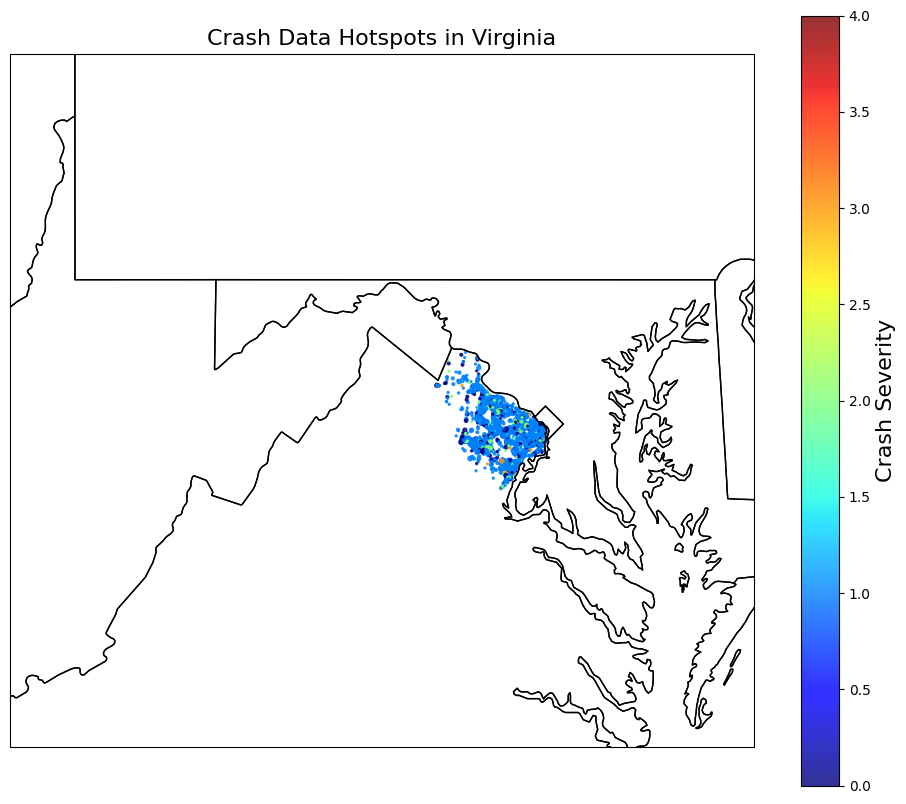

In [ ]:

#Plotting locations of the crashes, highlighting the number of people injured (by the size of the point) and the crash severity (by the color of the point)
#Plots points against a VA map
plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.Mercator())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

ax.set_extent([-81, -75.5, 37, 41], crs=ccrs.PlateCarree())
ax.set_aspect('equal')

scatter = ax.scatter(
    crash_data['X'],
    crash_data['Y'],
    s=crash_data['PERSONS_INJURED'] * 2,
    c=crash_data['CRASH_SEVERITY'].astype('category').cat.codes,
    cmap=plt.get_cmap("jet"),
    alpha=0.8,
    transform=ccrs.PlateCarree()
)
plt.title('Crash Data Hotspots in Virginia', fontsize=16)
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)
cbar = plt.colorbar(scatter)
cbar.set_label('Crash Severity', fontsize=16)
plt.show()

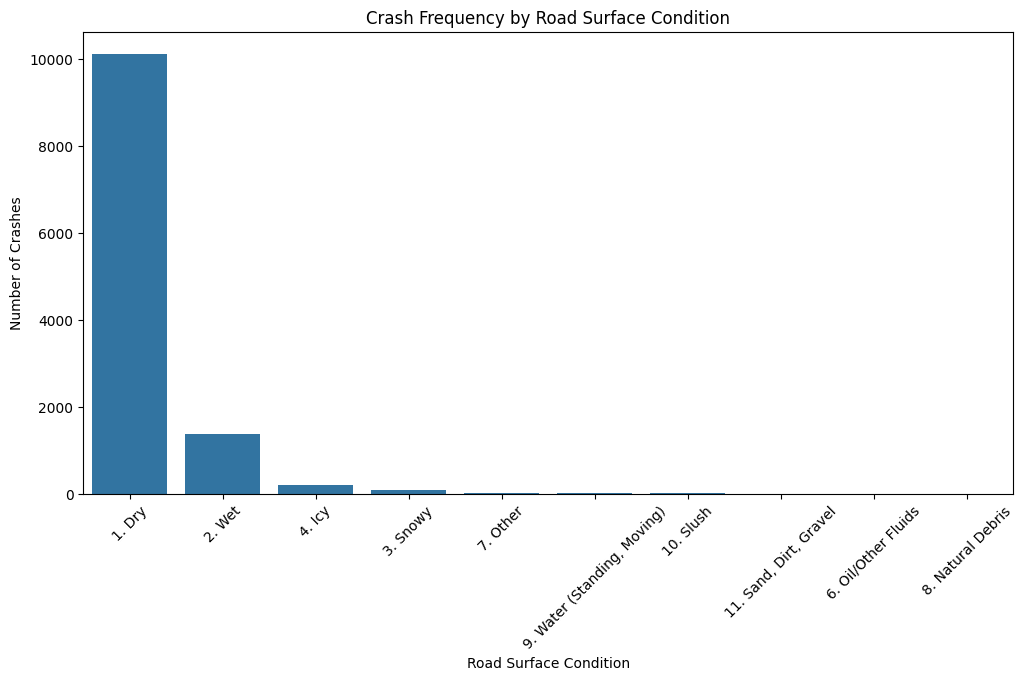

In [ ]:
# Ploting crash density by road surface condition
plt.figure(figsize=(12, 6))
sns.countplot(data=crashes_filtered, x='ROADWAY_SURFACE_COND', order=crashes_filtered['ROADWAY_SURFACE_COND'].value_counts().index)
plt.title("Crash Frequency by Road Surface Condition")
plt.xlabel("Road Surface Condition")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.show()

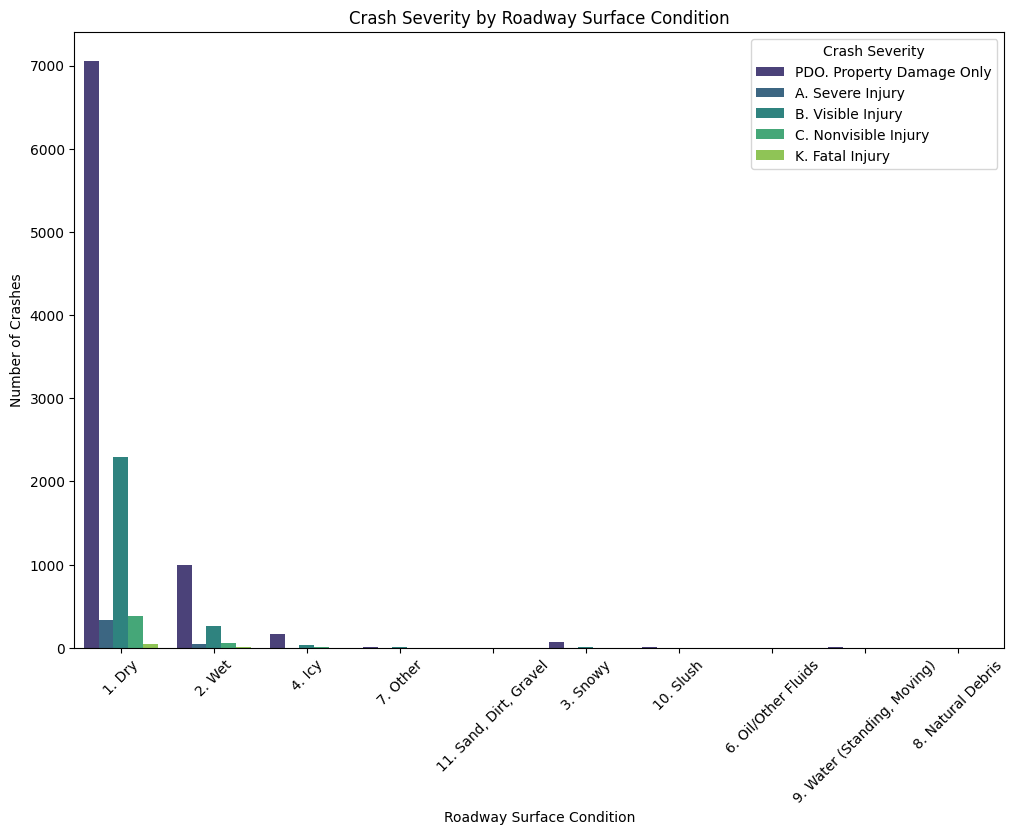

In [ ]:
#Comparison of road severity with varying road conditions
plt.figure(figsize=(12, 8))
sns.countplot(x='ROADWAY_SURFACE_COND', hue='CRASH_SEVERITY', data=crash_data, palette="viridis")
plt.title("Crash Severity by Roadway Surface Condition")
plt.xlabel("Roadway Surface Condition")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.legend(title='Crash Severity')
plt.show()

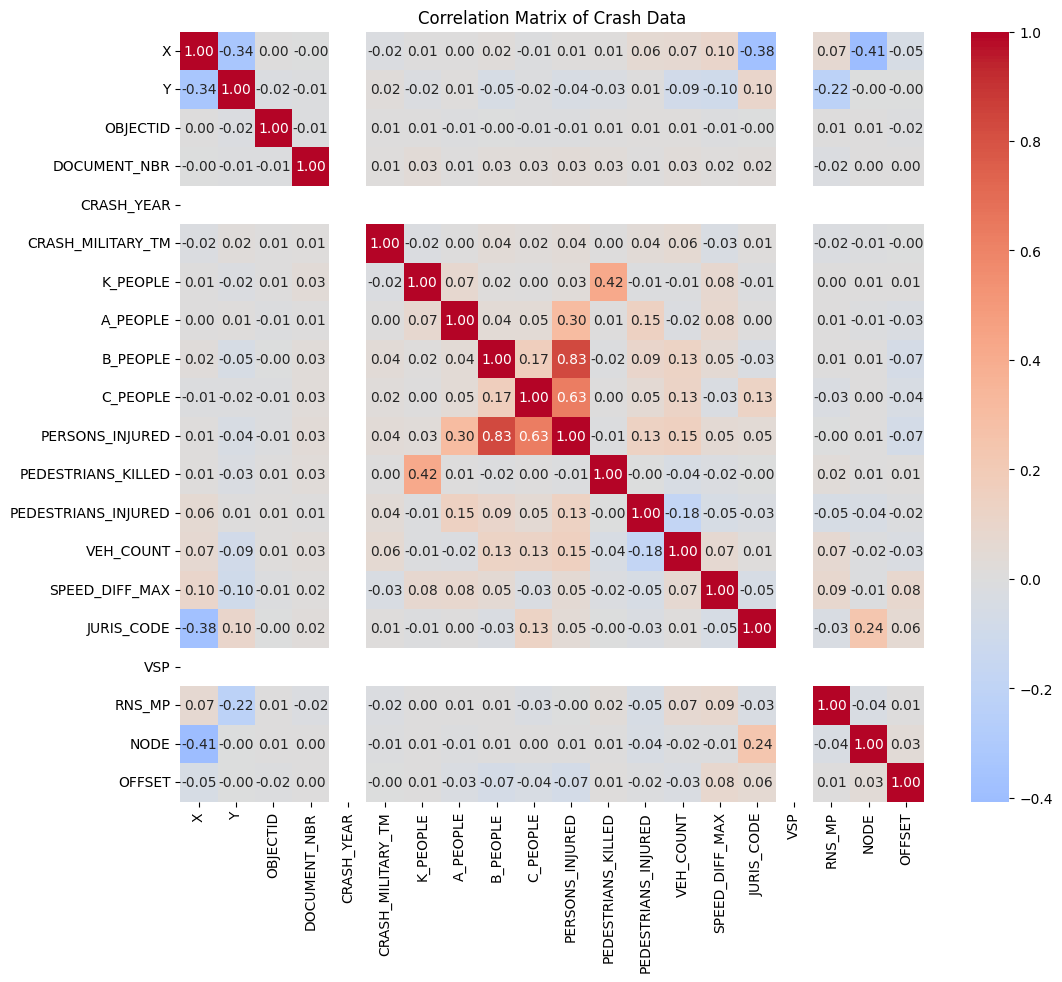

In [ ]:
#Correlation matrix heatmap
numeric_cols = crash_data.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = crash_data[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Crash Data")
plt.show()

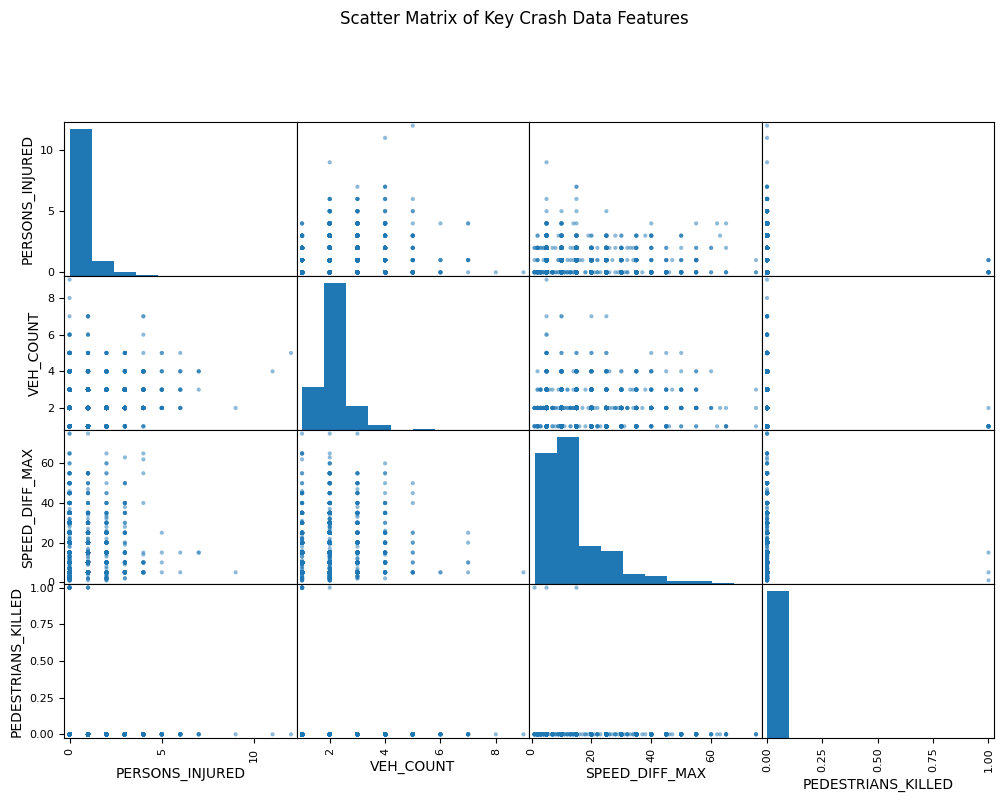

In [ ]:
#Scatter matrix
from pandas.plotting import scatter_matrix
attributes = [
    "PERSONS_INJURED",      # Number of people injured
    "VEH_COUNT",            # Number of vehicles involved
    "SPEED_DIFF_MAX",       # Maximum speed difference
    "ROADWAY_SURFACE_COND", # Roadway surface condition
    "ALCOHOL_NOTALCOHOL",   # Whether alcohol was involved
    "PEDESTRIANS_KILLED",   # Number of pedestrians killed
]

scatter_matrix(crash_data[attributes], figsize=(12, 8), diagonal="hist")
plt.suptitle("Scatter Matrix of Key Crash Data Features", y=1.02)
plt.show()

In [ ]:
crashes_filtered.value_counts('FIRST_HARMFUL_EVENT')

,count
FIRST_HARMFUL_EVENT,
20. Motor Vehicle In Transport,8839
6. Parked Vehicle,412
5. Guard Rail,354
11. Jersey Wall,337
23. Animal,253
2. Trees,238
19. Ped,207
28. Ran Off Road,171
3. Utility Pole,128


### Preparing Data and Cleaning



*   Limited to NOVA - 234k entry points vs 1 mil
*   2021-2024 for more recent and relevant crashes
*   Relevent features: X, Y, crash_severity, veh_count, weather_condition, light_condition, roadway_surfac





In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 22.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputClassifier
import matplotlib.pyplot as plt

data = crashes_filtered.copy()

# Drop columns with excessive missing values (>50%)
threshold = len(data) * 0.5
data = data.dropna(thresh=threshold, axis=1)

# Define target variables
target_classification = 'ROADWAY_SURFACE_COND'
target_regression = 'PERSONS_INJURED'

# Drop irrelevant or leakage columns
drop_cols = ['CRASH_DT', 'DOCUMENT_NBR', 'OBJECTID']
data = data.drop(columns=drop_cols)

# Define features and target
features = data.drop(columns=[target_classification, target_regression])
target_class = data[target_classification]
target_reg = data[target_regression]

# Save training features
trained_feature_list = features.columns.tolist()


# Train-test split
X_train, X_test, y_train_class, y_test_class = train_test_split(
    features, target_class, test_size=0.2, random_state=42, stratify=target_class)

_, _, y_train_reg, y_test_reg = train_test_split(
    features, target_reg, test_size=0.2, random_state=42)

# Preprocessing pipeline
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Classification Pipeline
classification_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Regression Pipeline
regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train models
classification_pipeline.fit(X_train, y_train_class)
regression_pipeline.fit(X_train, y_train_reg)

# Predict and evaluate
# -- Classification
y_pred_class = classification_pipeline.predict(X_test)
print("Classification Report")
print("Accuracy:", accuracy_score(y_test_class, y_pred_class))
print("Precision:", precision_score(y_test_class, y_pred_class, average='macro'))
print("Recall:", recall_score(y_test_class, y_pred_class, average='macro'))
print("F1 Score:", f1_score(y_test_class, y_pred_class, average='macro'))

# -- Regression
y_pred_reg = regression_pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print("\nRegression Report")
print("Root Mean Squared Error (RMSE):", rmse)

Classification Report
Accuracy: 0.9670050761421319
Precision: 0.4217342786145575
Recall: 0.2710827129659943
F1 Score: 0.2987778105789036

Regression Report
Root Mean Squared Error (RMSE): 0.9643339538869765


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Predict and Prioritize Risky Roads

# Create prediction feature set
inference_features = crashes_filtered.copy()

# Ensure all expected training columns are present
for col in trained_feature_list:
    if col not in inference_features.columns:
        inference_features[col] = np.nan  # or 'Unknown' for strings

# Reorder columns to match training
inference_features = inference_features[trained_feature_list]

# Predict
crashes_filtered['severity_score'] = regression_pipeline.predict(inference_features)
crashes_filtered['condition_pred'] = classification_pipeline.predict(inference_features)

# Map conditions to numeric scores
condition_score_map = {
    "1. Dry": 0, "2. Wet": 1, "3. Snowy": 2, "4. Icy": 3, "5. Muddy": 3,
    "6. Oil/Other Fluids": 3, "7. Other": 2, "8. Natural Debris": 3,
    "9. Water (Standing, Moving)": 3, "10. Slush": 3, "11. Sand, Dirt, Gravel": 3
}
crashes_filtered['condition_score'] = crashes_filtered['condition_pred'].map(condition_score_map).fillna(1)

# Compute risk score
crashes_filtered['risk_score'] = (
    crashes_filtered['severity_score'] * 2 + crashes_filtered['condition_score']
)

# Group and rank by route
priority_table = (
    crashes_filtered.groupby('RTE_NM')[['risk_score']]
    .mean()
    .sort_values(by='risk_score', ascending=False)
    .reset_index()
)

print("Prioritized Road Segments:")
display(priority_table)


Prioritized Road Segments:


,RTE_NM,risk_score
0,R-VA029SC00664EB,7.766667
1,R-VA076SC00706EB,7.660000
2,R-VA029SC07401SB,7.600000
3,R-VA029SC00628WB,7.040000
4,R-VA076SC03256NB,6.340000
...,...,...
2197,R-VA SR00241NB RMP001.00A,0.000000
2198,R-VA000SC06811WB,0.000000
2199,R-VA029SC00692WB,0.000000
2200,R-VA076SC02014SB,0.000000


##Hyperparameter Tuning: GridSearchCV and Bayesian Optimization (For RandomForestClassifier and RandomForestRegressor)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    classification_pipeline,
    param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train_class)
print("Best Params (Classifier):", grid_search.best_params_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best Params (Classifier): {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}


## Bayesian Optimization with skopt

In [ ]:
!pip install scikit-optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 9.2 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV

opt = BayesSearchCV(
    estimator=classification_pipeline,
    search_spaces={
        'classifier__n_estimators': (50, 200),
        'classifier__max_depth': (5, 30),
        'classifier__min_samples_split': (2, 10)
    },
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

opt.fit(X_train, y_train_class)
print("Best Params (Bayesian):", opt.best_params_)


Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


Best Params (Bayesian): OrderedDict([('classifier__max_depth', 30), ('classifier__min_samples_split', 2), ('classifier__n_estimators', 200)])


In [ ]:
print(data.columns.tolist())


['X', 'Y', 'CRASH_YEAR', 'CRASH_MILITARY_TM', 'CRASH_SEVERITY', 'K_PEOPLE', 'A_PEOPLE', 'B_PEOPLE', 'C_PEOPLE', 'PERSONS_INJURED', 'PEDESTRIANS_KILLED', 'PEDESTRIANS_INJURED', 'VEH_COUNT', 'COLLISION_TYPE', 'WEATHER_CONDITION', 'LIGHT_CONDITION', 'ROADWAY_SURFACE_COND', 'RELATION_TO_ROADWAY', 'ROADWAY_ALIGNMENT', 'ROADWAY_SURFACE_TYPE', 'ROADWAY_DEFECT', 'ROADWAY_DESCRIPTION', 'INTERSECTION_TYPE', 'TRAFFIC_CONTROL_TYPE', 'TRFC_CTRL_STATUS_TYPE', 'WORK_ZONE_RELATED', 'SCHOOL_ZONE', 'FIRST_HARMFUL_EVENT', 'FIRST_HARMFUL_EVENT_LOC', 'ALCOHOL_NOTALCOHOL', 'ANIMAL', 'BELTED_UNBELTED', 'BIKE_NONBIKE', 'DISTRACTED_NOTDISTRACTED', 'DROWSY_NOTDROWSY', 'DRUG_NODRUG', 'GR_NOGR', 'HITRUN_NOT_HITRUN', 'LGTRUCK_NONLGTRUCK', 'MOTOR_NONMOTOR', 'PED_NONPED', 'SPEED_NOTSPEED', 'RD_TYPE', 'INTERSECTION_ANALYSIS', 'SENIOR_NOTSENIOR', 'YOUNG_NOTYOUNG', 'MAINLINE_YN', 'NIGHT', 'VDOT_DISTRICT', 'JURIS_CODE', 'PHYSICAL_JURIS', 'FUN', 'FAC', 'AREA_TYPE', 'SYSTEM', 'VSP', 'OWNERSHIP', 'PLAN_DISTRICT', 'MPO_NAME

##Markov

In [ ]:
import pandas as pd

# 1. Load the data
data = load_data()

# 2. Keep relevant columns only
mdp_df = data[['RTE_NM', 'CRASH_YEAR', 'ROADWAY_SURFACE_COND']].dropna()

# 3. Clean data
mdp_df = mdp_df.sort_values(by=['RTE_NM', 'CRASH_YEAR'])

# 4. Get next year's condition per route
mdp_df['next_condition'] = mdp_df.groupby('RTE_NM')['ROADWAY_SURFACE_COND'].shift(-1)
mdp_df['next_year'] = mdp_df.groupby('RTE_NM')['CRASH_YEAR'].shift(-1)

# 5. Filter out invalid transitions (e.g., skip if year jumps)
mdp_df = mdp_df[(mdp_df['CRASH_YEAR'] + 1 == mdp_df['next_year'])]

# 6. Build transition count matrix
transition_counts = pd.crosstab(
    mdp_df['ROADWAY_SURFACE_COND'],
    mdp_df['next_condition']
)

# 7. Normalize to get transition probabilities
transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

# 8. Display
print("Transition Counts:\n", transition_counts)
print("\nTransition Probabilities:\n", transition_probs)


Transition Counts:
 next_condition               1. Dry  10. Slush  11. Sand, Dirt, Gravel  \
ROADWAY_SURFACE_COND                                                     
1. Dry                         1898          1                       5   
10. Slush                         2          0                       0   
11. Sand, Dirt, Gravel            1          0                       0   
2. Wet                          248          0                       0   
3. Snowy                         10          0                       1   
4. Icy                           38          0                       0   
7. Other                          6          0                       0   
8. Natural Debris                 1          0                       0   
9. Water (Standing, Moving)       1          0                       0   

next_condition               2. Wet  3. Snowy  4. Icy  5. Muddy  7. Other  \
ROADWAY_SURFACE_COND                                                        
1. Dry     

In [ ]:
import numpy as np
import pandas as pd

# States
states = ["Good", "Moderate", "Poor"]
state_idx = {s: i for i, s in enumerate(states)}

# Actions
actions = ["repair", "do_nothing"]

# Transition probabilities per action
# These are simplified, assumed values — you'd calibrate from your real data
P = {
    "repair": np.array([
        [0.9, 0.1, 0.0],  # Good stays Good
        [0.6, 0.3, 0.1],  # Moderate improves
        [0.4, 0.4, 0.2]   # Poor improves slowly
    ]),
    "do_nothing": np.array([
        [0.6, 0.3, 0.1],  # Good decays
        [0.1, 0.5, 0.4],  # Moderate decays more
        [0.0, 0.2, 0.8]   # Poor stays Poor
    ])
}

# Reward matrix: rows = state, cols = action
# Higher is better
R = np.array([
    [10,  5],  # Good: best if maintained
    [5,   0],  # Moderate: better to repair
    [0,  -5],  # Poor: big penalty if ignored
])

# Discount factor
gamma = 0.9

# Value Iteration
def value_iteration(P, R, gamma=0.9, theta=1e-4, max_iter=1000):
    V = np.zeros(len(states))
    policy = np.zeros(len(states), dtype=int)

    for it in range(max_iter):
        delta = 0
        for s in range(len(states)):
            q_sa = []
            for a in range(len(actions)):
                q = R[s, a] + gamma * np.dot(P[actions[a]][s], V)
                q_sa.append(q)
            max_q = max(q_sa)
            delta = max(delta, abs(max_q - V[s]))
            V[s] = max_q
            policy[s] = np.argmax(q_sa)
        if delta < theta:
            break
    return V, policy

# Run MDP
V, policy = value_iteration(P, R)

# Display
print("🧮 Optimal State Values:")
for s, v in zip(states, V):
    print(f"{s:>8}: {v:.2f}")

print("\n📋 Optimal Policy (0 = repair, 1 = do_nothing):")
for s, a in zip(states, policy):
    print(f"{s:>8}: {actions[a]}")


🧮 Optimal State Values:
    Good: 93.06
Moderate: 85.34
    Poor: 78.32

📋 Optimal Policy (0 = repair, 1 = do_nothing):
    Good: repair
Moderate: repair
    Poor: repair
